## Implementing Decision Tree Regression

**Last Updated: 8 Nov, 2025**

A Decision Tree Regressor predicts continuous values such as prices, scores, or temperatures using a tree-like structure. It splits data into smaller groups based on simple rules derived from input features, progressively reducing prediction errors. At the end of each branch (leaf node), the model outputs a value, typically the average of that group.

**Example:** To predict house prices using features like size, location, and age:
- First split: By location (expensive vs. affordable neighborhoods)
- Second split: By size (large vs. small houses)
- Final split: By age (old vs. new buildings)
- Leaf nodes: Output predicted price (average of similar houses)

---

## Implementation

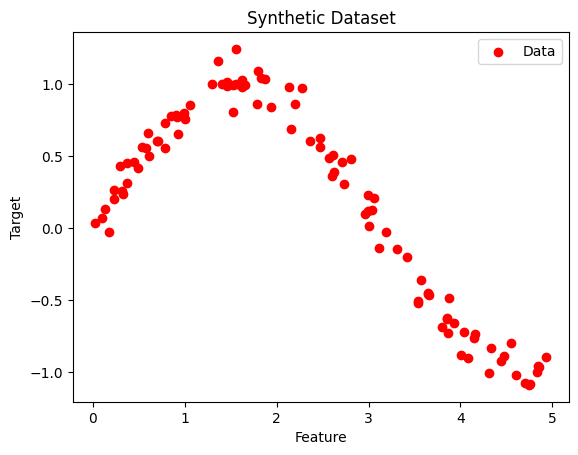

Mean Squared Error (MSE): 0.0151
Root Mean Squared Error (RMSE): 0.1229


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Creating a Sample Dataset
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

plt.scatter(X, y, color='red', label='Data')
plt.title("Synthetic Dataset")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.legend()
plt.show()

# Model training
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the Decision Tree Regressor
regressor = DecisionTreeRegressor(max_depth=4, random_state=42)
regressor.fit(X_train, Y_train)

# Display the tree structure
Y_pred = regressor.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {np.sqrt(mse):.4f}")

## <br>Visualizing the result

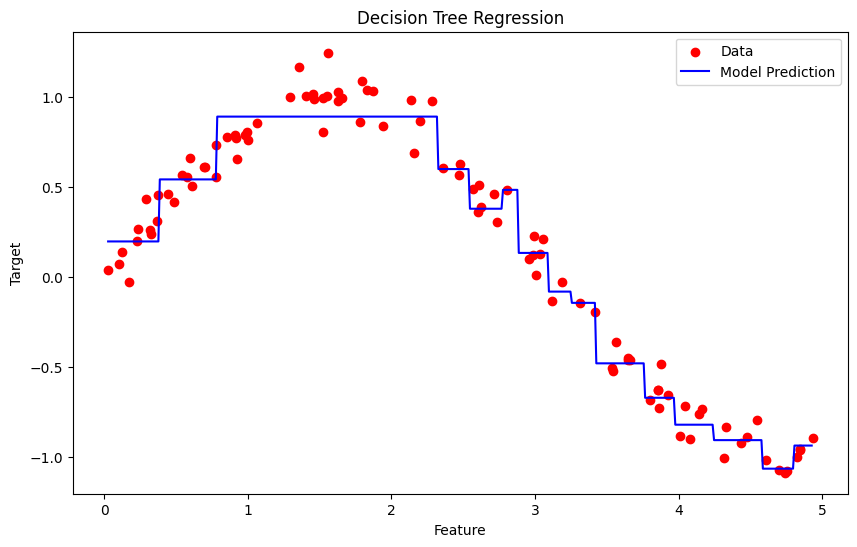

In [10]:
X_grid = np.arange(X.min(), X.max(), 0.01).reshape(-1, 1)  # Reshape to 2D array for prediction
Y_grid_pred = regressor.predict(X_grid)

plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='red', label='Data')
plt.plot(X_grid, Y_grid_pred, color='blue', label='Model Prediction')

plt.title("Decision Tree Regression")
plt.xlabel("Feature")
plt.ylabel("Target")

plt.legend()

plt.show()

## <br>Export and Show the Tree Structure below

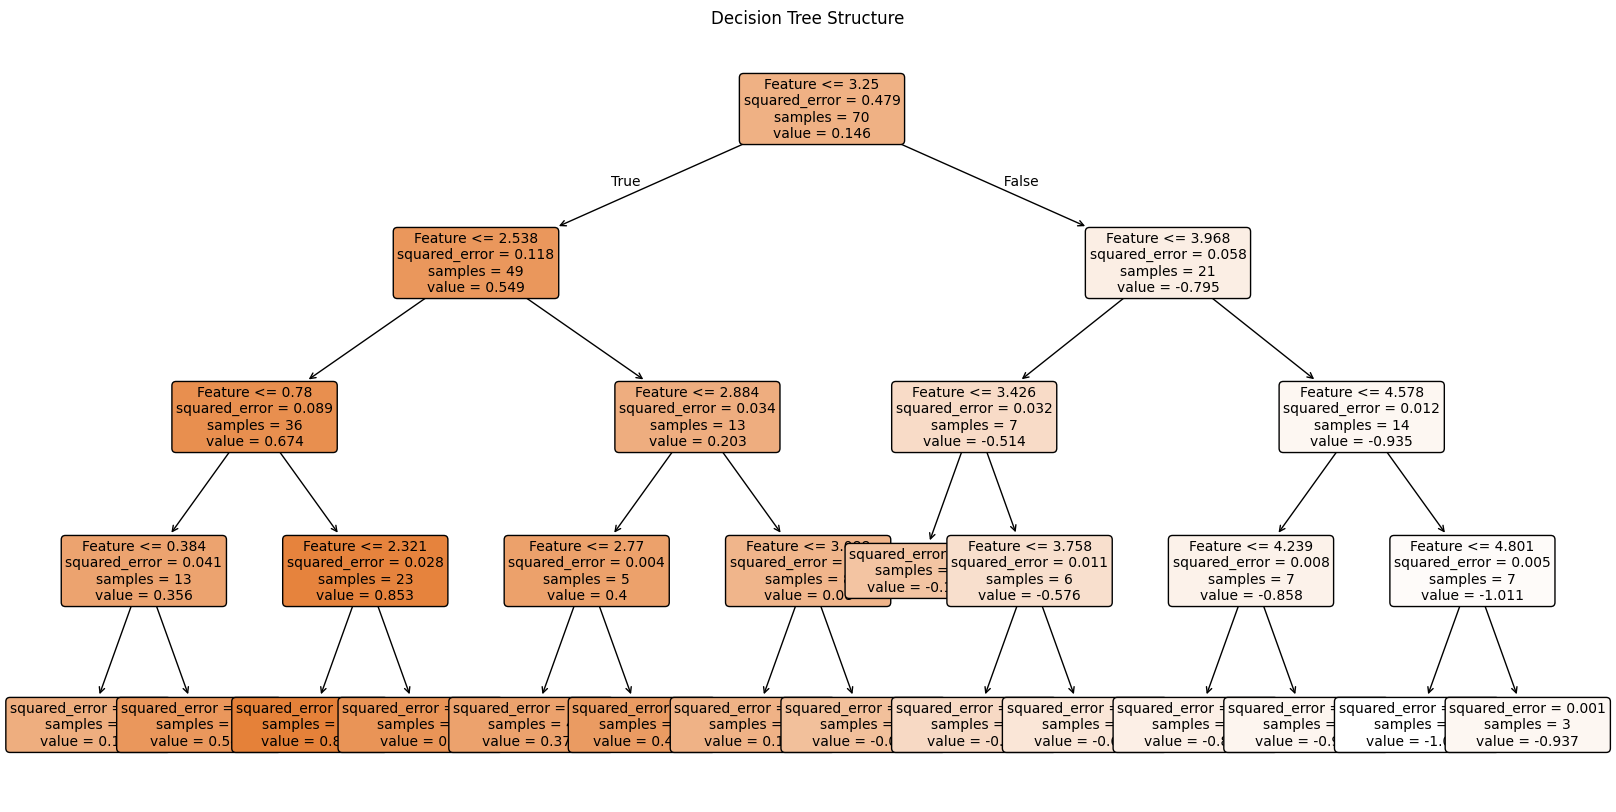

In [11]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    regressor,
    feature_names=["Feature"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Structure")
plt.show()